In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
from sklearn_extra.cluster import CLARA

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#load embedding matrices
t1_euclidean_embeddings  = np.load('../exps/eval_t1_hierarchical_split/euclidean/hyp_embeddings.npy', allow_pickle=True)
t1_euclidean_labels      = np.load('../exps/eval_t1_hierarchical_split/euclidean/hyp_labels.npy', allow_pickle=True)
t1_euclidean_match_flags = np.load('../exps/eval_t1_hierarchical_split/euclidean/hyp_match_flags.npy', allow_pickle=True)

t2_euclidean_embeddings  = np.load('../exps/eval_t2_ft_hierarchical_split/euclidean/hyp_embeddings.npy', allow_pickle=True)
t2_euclidean_labels      = np.load('../exps/eval_t2_ft_hierarchical_split/euclidean/hyp_labels.npy', allow_pickle=True)
t2_euclidean_match_flags = np.load('../exps/eval_t2_ft_hierarchical_split/euclidean/hyp_match_flags.npy', allow_pickle=True)

t3_euclidean_embeddings  = np.load('../exps/eval_t3_ft_hierarchical_split/euclidean/hyp_embeddings.npy', allow_pickle=True)
t3_euclidean_labels      = np.load('../exps/eval_t3_ft_hierarchical_split/euclidean/hyp_labels.npy', allow_pickle=True)
t3_euclidean_match_flags = np.load('../exps/eval_t3_ft_hierarchical_split/euclidean/hyp_match_flags.npy', allow_pickle=True)

t4_euclidean_embeddings  = np.load('../exps/eval_t4_ft_hierarchical_split/euclidean/hyp_embeddings.npy', allow_pickle=True)
t4_euclidean_labels      = np.load('../exps/eval_t4_ft_hierarchical_split/euclidean/hyp_labels.npy', allow_pickle=True)
t4_euclidean_match_flags = np.load('../exps/eval_t4_ft_hierarchical_split/euclidean/hyp_match_flags.npy', allow_pickle=True)

superclass_map = {0:'vehicle', 1:'vehicle', 2:'outdoor', 3:'outdoor', 4:'animal', 5:'animal', 6:'animal', 7:'accessory', 8:'sports', 9:'sports', 10:'kitchen', 
                  11:'kitchen',12:'food', 13:'food', 14:'furniture', 15:'furniture', 16:'electronic', 17:'appliance',  18:'appliance', 19:'indoor', #end task 1 

                  20:'person', 21:'vehicle', 22:'vehicle', 23:'outdoor', 24:'animal', 25:'animal', 26:'accessory', 27:'sports', 28:'sports', 29:'kitchen',
                  30:'food',  31:'food', 32:'food',  33:'furniture', 34:'furniture', 35:'electronic', 36:'electronic', 37:'appliance',  38:'indoor', 39:'indoor', #end task 2

                  40: 'vehicle', 41: 'vehicle', 42: 'outdoor', 43: 'animal', 44: 'animal', 45: 'animal', 46: 'accessory', 47: 'sports', 48: 'sports', 49: 'sports', 50: 'kitchen',
                  51: 'kitchen', 52: 'food', 53: 'food', 54: 'kitchen', 55: 'electronic', 56: 'electronic', 57: 'appliance', 58: 'indoor', 59: 'indoor',#end task 3

                  60: 'vehicle', 61: 'vehicle', 62: 'outdoor', 63: 'animal', 64: 'animal', 65: 'accessory', 66: 'accessory', 67: 'sports', 68: 'sports', 69: 'sports', 
                  70: 'kitchen', 71: 'kitchen', 72: 'food', 73: 'food', 74: 'food', 75: 'kitchen', 76: 'electronic', 77: 'appliance', 78: 'indoor', 79: 'indoor' #end task 4
                  }

#*****************************T1********************************************
t1_emb_euclidean         = t1_euclidean_embeddings.reshape(-1, 256)
t1_labels_euclidean      = t1_euclidean_labels.reshape(-1)
t1_match_flags_euclidean = t1_euclidean_match_flags.reshape(-1)

t1_euclidean_embeddings_matched = t1_emb_euclidean[t1_match_flags_euclidean]
t1_euclidean_labels_matched = t1_labels_euclidean[t1_match_flags_euclidean]

t1_euclidean_emb_mask = t1_euclidean_labels_matched != 80 
t1_euclidean_labels_known = t1_euclidean_labels_matched[t1_euclidean_emb_mask]
t1_euclidean_embeddings_known = t1_euclidean_embeddings_matched[t1_euclidean_emb_mask]
#*****************************T2********************************************
t2_emb_euclidean         = t2_euclidean_embeddings.reshape(-1, 256)
t2_labels_euclidean      = t2_euclidean_labels.reshape(-1)
t2_match_flags_euclidean = t2_euclidean_match_flags.reshape(-1)

t2_euclidean_embeddings_matched = t2_emb_euclidean[t2_match_flags_euclidean]
t2_euclidean_labels_matched = t2_labels_euclidean[t2_match_flags_euclidean]

t2_euclidean_emb_mask = t2_euclidean_labels_matched != 80 
t2_euclidean_labels_known = t2_euclidean_labels_matched[t2_euclidean_emb_mask]
t2_euclidean_embeddings_known = t2_euclidean_embeddings_matched[t2_euclidean_emb_mask]
#***********************************T3**************************************
t3_emb_euclidean                 = t3_euclidean_embeddings.reshape(-1, 256)
t3_labels_euclidean              = t3_euclidean_labels.reshape(-1)
t3_match_flags_euclidean         = t3_euclidean_match_flags.reshape(-1)

t3_euclidean_embeddings_matched  = t3_emb_euclidean[t3_match_flags_euclidean]
t3_euclidean_labels_matched      = t3_labels_euclidean[t3_match_flags_euclidean]

t3_euclidean_emb_mask            = t3_euclidean_labels_matched != 80 
t3_euclidean_labels_known        = t3_euclidean_labels_matched[t3_euclidean_emb_mask]
t3_euclidean_embeddings_known    = t3_euclidean_embeddings_matched[t3_euclidean_emb_mask]
#***********************************T4**************************************
t4_emb_euclidean                 = t4_euclidean_embeddings.reshape(-1, 256)
t4_labels_euclidean              = t4_euclidean_labels.reshape(-1)
t4_match_flags_euclidean         = t4_euclidean_match_flags.reshape(-1)

t4_euclidean_embeddings_matched  = t4_emb_euclidean[t4_match_flags_euclidean]
t4_euclidean_labels_matched      = t4_labels_euclidean[t4_match_flags_euclidean]

t4_euclidean_emb_mask            = t4_euclidean_labels_matched != 80 
t4_euclidean_labels_known        = t4_euclidean_labels_matched[t4_euclidean_emb_mask]
t4_euclidean_embeddings_known    = t4_euclidean_embeddings_matched[t4_euclidean_emb_mask]

In [39]:
prototype_bank = dict()
replay_buffer = dict()

#set limits for replay buffer
num_samples = 1000
rep_frac = 0.7
hard_frac = 1 - rep_frac

#rng
seed=42

#shots
shot_size=10

#samples
rep_samples  = int(rep_frac * num_samples)
hard_samples = int(hard_frac * num_samples)

def map_to_superclasses(labels, superclass_map):
    return np.array([superclass_map[int(y)] for y in labels], dtype=object)

def l2_normalize(x):
    # pca = PCA(n_components=16, random_state=42)
    # class_embeddings_reduced = pca.fit_transform(x)
    return x / (np.linalg.norm(x, axis=1, keepdims=True))

def cosine_loss(a, b, axis=-1):
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)

    dot = np.sum(a * b, axis=axis)
    norm_a = np.linalg.norm(a, axis=axis)
    norm_b = np.linalg.norm(b, axis=axis)

    cos_sim = dot / (norm_a * norm_b)
    return 1.0 - cos_sim

In [53]:
def rep_items(X, centers):
    chosen = []
    used = set()

    for center in centers:
        dists = np.linalg.norm(X-center, axis=1)
        order = np.argsort(dists)
        for idx in order:
            if idx not in used:
                used.add(idx)
                chosen.append(idx)
                break
    return np.array(chosen, dtype=int)

def select_representative_examples(class_emb):
    if len(class_emb) <= rep_samples:
        return class_emb.copy()

    k_eff = min(rep_samples, len(class_emb))
    km = KMeans(n_clusters=k_eff, random_state=seed, n_init=10)
    km.fit(class_emb)

    rep_idx = rep_items(class_emb, km.cluster_centers_)
    return class_emb[rep_idx]

def hard_scores(class_emb, class_num, prototypes):
    true_protos = prototypes[class_num]
    d_true = np.min(cosine_loss(class_emb[:, None, :], true_protos[None, :, :], axis=2),axis=1)

    d_wrong = np.full(len(class_emb), np.inf)

    for other_cls, other_protos in prototypes.items():
        if other_cls == class_num:
            continue
        d_cls = np.min(cosine_loss(class_emb[:, None, :], other_protos[None, :, :], axis=2),axis=1)
        d_wrong = np.minimum(d_wrong, d_cls)

    margins = d_wrong - d_true
    return margins

def select_hard_examples(class_emb, class_num, prototypes):
    if len(class_emb) <= hard_samples:
        return class_emb.copy()

    margins = hard_scores(class_emb, class_num, prototypes)
    hard_idx = np.argsort(margins)[:hard_samples]
    return class_emb[hard_idx]

def update_replay_buffer(support_emb, support_labels, prototype_bank, replay_buffer, superclass_list):
    new_buffer = {k: v.copy() for k, v in replay_buffer.items()}

    for superclass in superclass_list:
        superclass_emb = support_emb[support_labels == superclass]
        if len(superclass_emb) == 0:
            continue

        parts = []

        rep = select_representative_examples(superclass_emb)
        if len(rep) > 0:
            parts.append(rep)

        if len(prototype_bank) > 1 and hard_samples > 0:
            hard = select_hard_examples(superclass_emb, superclass, prototype_bank)
            if len(hard) > 0:
                parts.append(hard)

        if superclass in new_buffer and len(new_buffer[superclass]) > 0:
            parts.append(new_buffer[superclass])

        if len(parts) == 0:
            continue

        combined = np.vstack(parts)
        combined = np.unique(combined, axis=0)

        if len(combined) > num_samples:
            combined = combined[:num_samples]

        new_buffer[superclass] = combined

    return new_buffer

In [35]:
def split_data(emb, class_labels, query_size):
    rng = np.random.default_rng(seed)

    support_x, support_class = [], []
    query_x, query_class = [], []

    for cls in np.unique(class_labels):
        idx = np.where(class_labels == cls)[0]
        rng.shuffle(idx)
        print(len(idx))

        # keep at least 1 query example when possible
        n_support = min(shot_size, max(1, len(idx) - 1))

        if query_size is None:
            n_query = len(idx) - n_support
        else:
            n_query = min(query_size, len(idx) - n_support)

        if n_query <= 0:
            continue

        support_idx = idx[:n_support]
        query_idx = idx[n_support:n_support + n_query]

        support_x.append(emb[support_idx])
        support_class.append(class_labels[support_idx])

        query_x.append(emb[query_idx])
        query_class.append(class_labels[query_idx])

    support_x = np.concatenate(support_x, axis=0)
    support_class = np.concatenate(support_class, axis=0)
    query_x = np.concatenate(query_x, axis=0)
    query_class = np.concatenate(query_class, axis=0)

    support_superclass = map_to_superclasses(support_class, superclass_map)
    query_superclass = map_to_superclasses(query_class, superclass_map)

    return (
        support_x,
        support_superclass,
        support_class,
        query_x,
        query_superclass,
        query_class)

In [ ]:
def create_superclass_prototypes(support_emb, support_sc_labels, replay_buffer, superclass_list, k):
    global prototype_bank

    for sc in superclass_list:
        current_mem = []

        if sc in replay_buffer and len(replay_buffer[sc]) > 0:
            current_mem.append(replay_buffer[sc])

        current_support = support_emb[support_sc_labels == sc]
        if len(current_support) > 0:
            current_mem.append(current_support)

        if len(current_mem) == 0:
            continue

        support_2d = np.vstack(current_mem)

        k_eff = min(k, len(support_2d))
        model = CLARA(n_clusters=k_eff, metric="cosine", random_state=seed)
        model.fit(support_2d)
        prototype_bank[sc] = model.cluster_centers_

def predict_superclass(query, prototype_bank):
    pred_sc = None
    min_dist = float("inf")

    for sc, proto_list in prototype_bank.items():
        dist = [cosine_loss(query, proto) for proto in proto_list]
        min_sc_dist = np.min(dist)

        if min_sc_dist < min_dist:
            min_dist = min_sc_dist
            pred_sc = sc

    return pred_sc, min_dist

def batch_predict_superclass(query_emb, prototype_bank):
    preds, dists = [], []
    for q in query_emb:
        p, d = predict_superclass(q, prototype_bank)
        preds.append(p)
        dists.append(d)
    return np.array(preds, dtype=object), np.array(dists)

In [7]:
def class_to_superclass_accuracy_table(y_true_class, y_true_sc, y_pred_sc, superclass_map):
    rows = []
    for cls in np.unique(y_true_class):
        mask = (y_true_class == cls)
        true_sc = superclass_map[int(cls)]
        rows.append({
            "class_id": int(cls),
            "superclass": true_sc,
            "n_query": int(mask.sum()),
            "accuracy": float((y_pred_sc[mask] == y_true_sc[mask]).mean())
        })
    return pd.DataFrame(rows).sort_values(["accuracy", "n_query"], ascending=[True, False]).reset_index(drop=True)


def superclass_internal_variation_table(y_true_class, y_true_sc, y_pred_sc, superclass_map):
    class_df = class_to_superclass_accuracy_table(y_true_class, y_true_sc, y_pred_sc, superclass_map)
    out = (
        class_df.groupby("superclass", as_index=False)
        .agg(
            num_classes=("class_id", "count"),
            mean_class_acc=("accuracy", "mean"),
            std_class_acc=("accuracy", "std"),
            min_class_acc=("accuracy", "min"),
            max_class_acc=("accuracy", "max"),
        )
        .sort_values("std_class_acc", ascending=False)
        .reset_index(drop=True)
    )
    return out


def superclass_accuracy_table(y_true_sc, y_pred_sc, superclass_map=None):
    y_true_sc = np.asarray(y_true_sc, dtype=object)
    y_pred_sc = np.asarray(y_pred_sc, dtype=object)

    rows = []
    for sc in sorted(np.unique(y_true_sc)):
        mask = (y_true_sc == sc)
        rows.append({
            "superclass": sc,
            "n_query": int(mask.sum()),
            "accuracy": float((y_pred_sc[mask] == y_true_sc[mask]).mean())
        })

    return pd.DataFrame(rows).sort_values(["accuracy", "n_query"], ascending=[True, False]).reset_index(drop=True)

In [8]:
def run_incremental_fewshot(tasks, k=3):
    global prototype_bank
    prototype_bank = {}
    replay_buffer = {}

    seen_superclasses = []
    results = []
    per_task_details = []

    for task_id, (
        support_emb,
        support_sc_labels,
        support_class_labels,
        query_emb,
        query_sc_labels,
        query_class_labels
    ) in enumerate(tasks, start=1):

        task_superclasses = sorted(np.unique(np.concatenate([support_sc_labels, query_sc_labels])).tolist())
        seen_superclasses = sorted(set(seen_superclasses).union(task_superclasses))

        create_superclass_prototypes(
            support_emb=support_emb,
            support_sc_labels=support_sc_labels,
            replay_buffer=replay_buffer,
            superclass_list=seen_superclasses,k=k)

        preds_sc, dists = batch_predict_superclass(query_emb, prototype_bank)
        acc = np.mean(preds_sc == query_sc_labels) if len(query_sc_labels) > 0 else np.nan

        class_table = class_to_superclass_accuracy_table(
            query_class_labels, query_sc_labels, preds_sc, superclass_map
        )
        superclass_table = superclass_accuracy_table(query_sc_labels, preds_sc, superclass_map)
        superclass_variation_table = superclass_internal_variation_table(
            query_class_labels, query_sc_labels, preds_sc, superclass_map
        )

        results.append({
            "task": task_id,
            "accuracy": acc,
            "num_seen_superclasses": len(seen_superclasses),
            "macro_class_acc": class_table["accuracy"].mean(),   # per-class superclass accuracy
            "class_acc_std": class_table["accuracy"].std(ddof=0),
            "macro_superclass_acc": superclass_table["accuracy"].mean(),
            "superclass_acc_std": superclass_table["accuracy"].std(ddof=0),
        })

        per_task_details.append({
            "task": task_id,
            "y_true": query_sc_labels.copy(),       # keep old key name for compatibility
            "y_pred": preds_sc.copy(),              # keep old key name for compatibility
            "y_true_class": query_class_labels.copy(),
            "dists": dists.copy(),
            "class_table": class_table,
            "superclass_table": superclass_table,
            "superclass_variation_table": superclass_variation_table,
        })

        replay_buffer = update_replay_buffer(
            support_emb=support_emb,
            support_labels=support_sc_labels,
            prototype_bank=prototype_bank,
            replay_buffer=replay_buffer,
            superclass_list=task_superclasses,
        )

    return results, replay_buffer, per_task_details


def test_incremental_fewshot(tasks):
    results = []
    per_task_details = []
    seen_superclasses = sorted(prototype_bank.keys())

    for task_id, (emb, sc_labels, class_labels) in enumerate(tasks, start=1):
        preds_sc, dists = batch_predict_superclass(emb, prototype_bank)
        acc = np.mean(preds_sc == sc_labels) if len(sc_labels) > 0 else np.nan

        class_table = class_to_superclass_accuracy_table(
            class_labels, sc_labels, preds_sc, superclass_map
        )
        superclass_table = superclass_accuracy_table(sc_labels, preds_sc, superclass_map)
        superclass_variation_table = superclass_internal_variation_table(
            class_labels, sc_labels, preds_sc, superclass_map
        )

        results.append({
            "task": task_id,
            "accuracy": acc,
            "num_seen_superclasses": len(seen_superclasses),
            "macro_class_acc": class_table["accuracy"].mean(),
            "class_acc_std": class_table["accuracy"].std(ddof=0),
            "macro_superclass_acc": superclass_table["accuracy"].mean(),
            "superclass_acc_std": superclass_table["accuracy"].std(ddof=0)})

        per_task_details.append({
            "task": task_id,
            "y_true": sc_labels.copy(),
            "y_pred": preds_sc.copy(),
            "y_true_class": class_labels.copy(),
            "dists": dists.copy(),
            "class_table": class_table,
            "superclass_table": superclass_table,
            "superclass_variation_table": superclass_variation_table})

    return results, per_task_details

In [9]:
def superclass_labels(y, superclass_map=None):
    y = np.asarray(y)
    if y.dtype.kind in {"U", "S", "O"}:
        return y.astype(object)
    return np.array([superclass_map[int(x)] for x in y], dtype=object)


def normalized_confusion(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm = cm.astype(float)
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm), where=row_sums != 0)
    return pd.DataFrame(cm_norm, index=labels, columns=labels)


def superclass_confusion_table(y_true, y_pred, superclass_map=None):
    true_sc = superclass_labels(y_true, superclass_map)
    pred_sc = superclass_labels(y_pred, superclass_map)
    labels = sorted(np.unique(np.concatenate([true_sc, pred_sc])))
    return normalized_confusion(true_sc, pred_sc, labels)

def show_confusion_matrix_image(y_true, y_pred, superclass_map=None, title="Superclass Confusion Matrix"):
    cm_df = superclass_confusion_table(y_true, y_pred, superclass_map)
    cm = cm_df.values
    labels = cm_df.index.tolist()

    n = len(labels)
    fig_size = max(10, 0.9 * n + 2)

    fig, ax = plt.subplots(figsize=(fig_size, fig_size))
    im = ax.imshow(cm, vmin=0.0, vmax=1.0, interpolation="nearest")

    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)

    ax.set_xlabel("Predicted superclass")
    ax.set_ylabel("True superclass")
    ax.set_title(title)

    cbar = fig.colorbar(im, ax=ax)
    cbar.ax.set_ylabel("Value", rotation=270, labelpad=15)

    for i in range(n):
        for j in range(n):
            ax.text(
                j, i,
                f"{cm[i, j]:.2f}",
                ha="center",
                va="center",
                fontsize=9
            )

    plt.tight_layout()
    plt.show()

def compact_summary_table(results, per_task_details):
    rows = []

    for r, d in zip(results, per_task_details):
        y_true = np.asarray(d["y_true"], dtype=object)
        y_pred = np.asarray(d["y_pred"], dtype=object)

        task_acc = float((y_true == y_pred).mean())
        cross_superclass_error = float((y_true != y_pred).mean())

        sc_table = superclass_accuracy_table(y_true, y_pred)
        mean_acc = float(sc_table["accuracy"].mean())
        std_acc = float(sc_table["accuracy"].std(ddof=0))

        rows.append({
            "task": int(r["task"]),
            "task_accuracy": task_acc,
            "cross_superclass_error": cross_superclass_error,
            "mean_superclass_acc": mean_acc,
            "std_superclass_acc": std_acc,
        })

    out = pd.DataFrame(rows)

    return out.round({"task_accuracy": 4,
                      "cross_superclass_error": 4,
                      "mean_superclass_acc": 4,
                      "std_superclass_acc": 4, })

def print_task_report(per_task_details, idx):
    d = per_task_details[idx]

    print(f"\n================ TASK {idx + 1} ================")
    show_confusion_matrix_image(
        d["y_true"],
        d["y_pred"],
        title=f"Task {idx + 1} Superclass Confusion Matrix")

In [41]:
query_size = 9

t1_support_emb, t1_support_sc, t1_support_class, t1_query_emb, t1_query_sc, t1_query_class = split_data(
    l2_normalize(t1_euclidean_embeddings_known), t1_euclidean_labels_known, query_size=query_size)
t2_support_emb, t2_support_sc, t2_support_class, t2_query_emb, t2_query_sc, t2_query_class = split_data(
    l2_normalize(t2_euclidean_embeddings_known), t2_euclidean_labels_known, query_size=query_size)
t3_support_emb, t3_support_sc, t3_support_class, t3_query_emb, t3_query_sc, t3_query_class = split_data(
    l2_normalize(t3_euclidean_embeddings_known), t3_euclidean_labels_known, query_size=query_size)
t4_support_emb, t4_support_sc, t4_support_class, t4_query_emb, t4_query_sc, t4_query_class = split_data(
    l2_normalize(t4_euclidean_embeddings_known), t4_euclidean_labels_known, query_size=query_size)

train_tasks = [
    (t1_support_emb, t1_support_sc, t1_support_class, t1_query_emb, t1_query_sc, t1_query_class),
    (t2_support_emb, t2_support_sc, t2_support_class, t2_query_emb, t2_query_sc, t2_query_class),
    (t3_support_emb, t3_support_sc, t3_support_class, t3_query_emb, t3_query_sc, t3_query_class),
    (t4_support_emb, t4_support_sc, t4_support_class, t4_query_emb, t4_query_sc, t4_query_class)]

test_tasks = [
    (t1_query_emb, t1_query_sc, t1_query_class),
    (t2_query_emb, t2_query_sc, t2_query_class),
    (t3_query_emb, t3_query_sc, t3_query_class),
    (t4_query_emb, t4_query_sc, t4_query_class)]

316
1932
637
101
440
202
218
371
115
241
1025
343
379
239
1791
261
288
55
143
1161
316
1932
637
101
440
202
218
371
115
241
1025
343
379
239
1791
261
288
55
143
1161
11004
371
143
75
273
361
413
69
263
899
177
287
316
343
163
231
106
9
267
277
316
1932
637
101
440
202
218
371
115
241
1025
343
379
239
1791
261
288
55
143
1161
11004
371
143
75
273
361
413
69
263
899
177
287
316
343
163
231
106
9
267
277
285
190
60
380
255
71
540
336
146
148
215
326
371
127
697
283
153
225
36
191
316
1932
637
101
440
202
218
371
115
241
1025
343
379
239
1791
261
288
55
143
1161
11004
371
143
75
273
361
413
69
263
899
177
287
316
343
163
231
106
9
267
277
285
190
60
380
255
71
540
336
146
148
215
326
371
127
697
283
153
225
36
191
415
430
413
268
232
254
303
179
269
225
253
626
285
338
316
179
262
126
11
57


   task  task_accuracy  cross_superclass_error  mean_superclass_acc  \
0     1         0.9111                  0.0889               0.9057   
1     2         0.8011                  0.1989               0.8008   
2     3         0.7707                  0.2293               0.7770   
3     4         0.7273                  0.2727               0.7211   

   std_superclass_acc  
0              0.0763  
1              0.0490  
2              0.1036  
3              0.1109  

================ TASK 1 ================


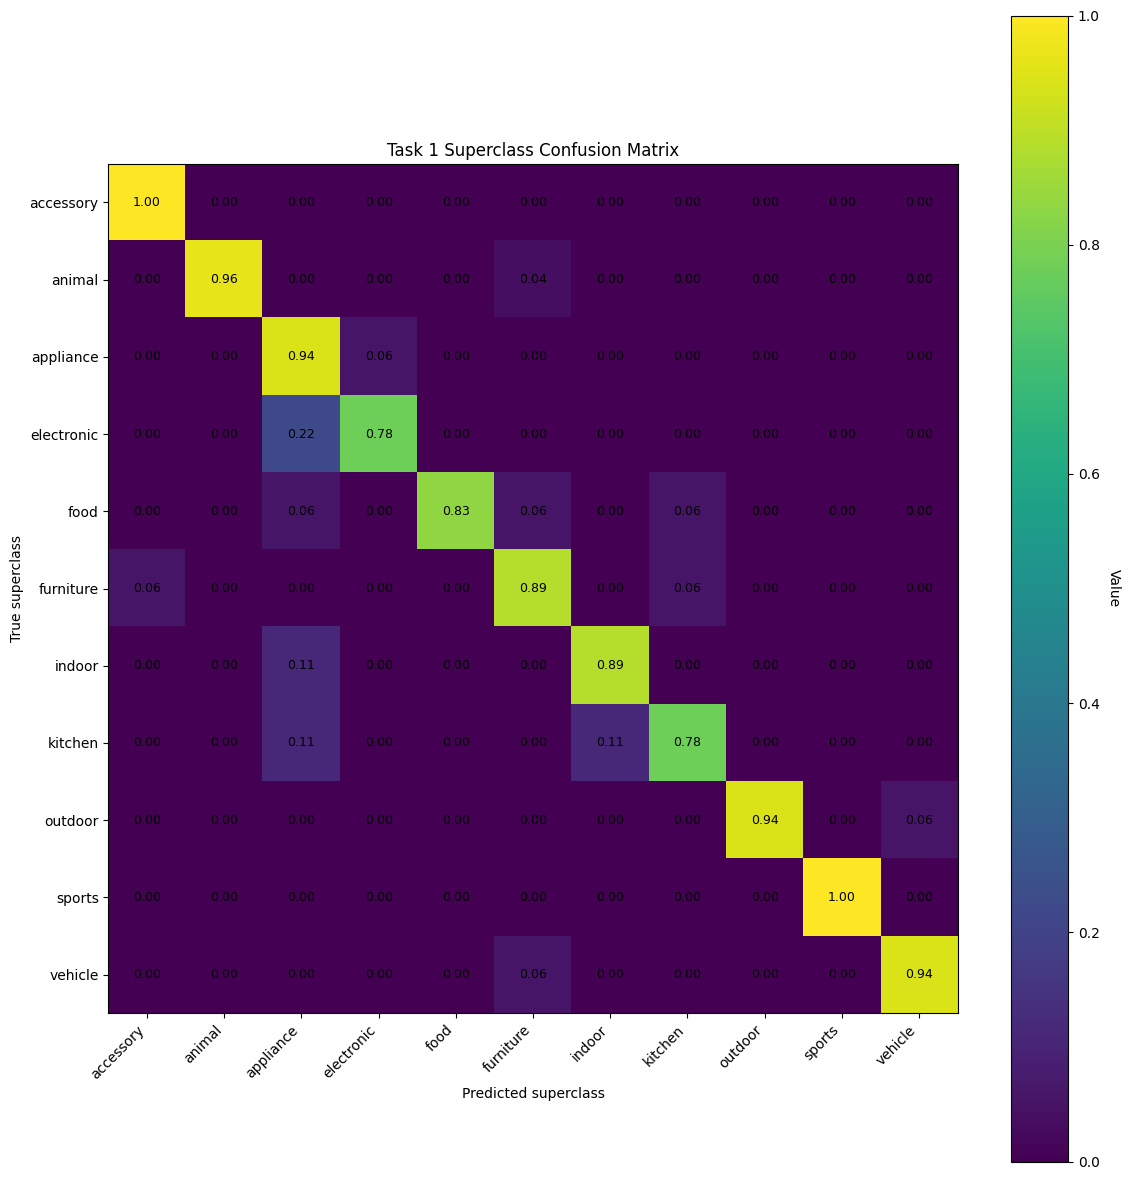


================ TASK 2 ================


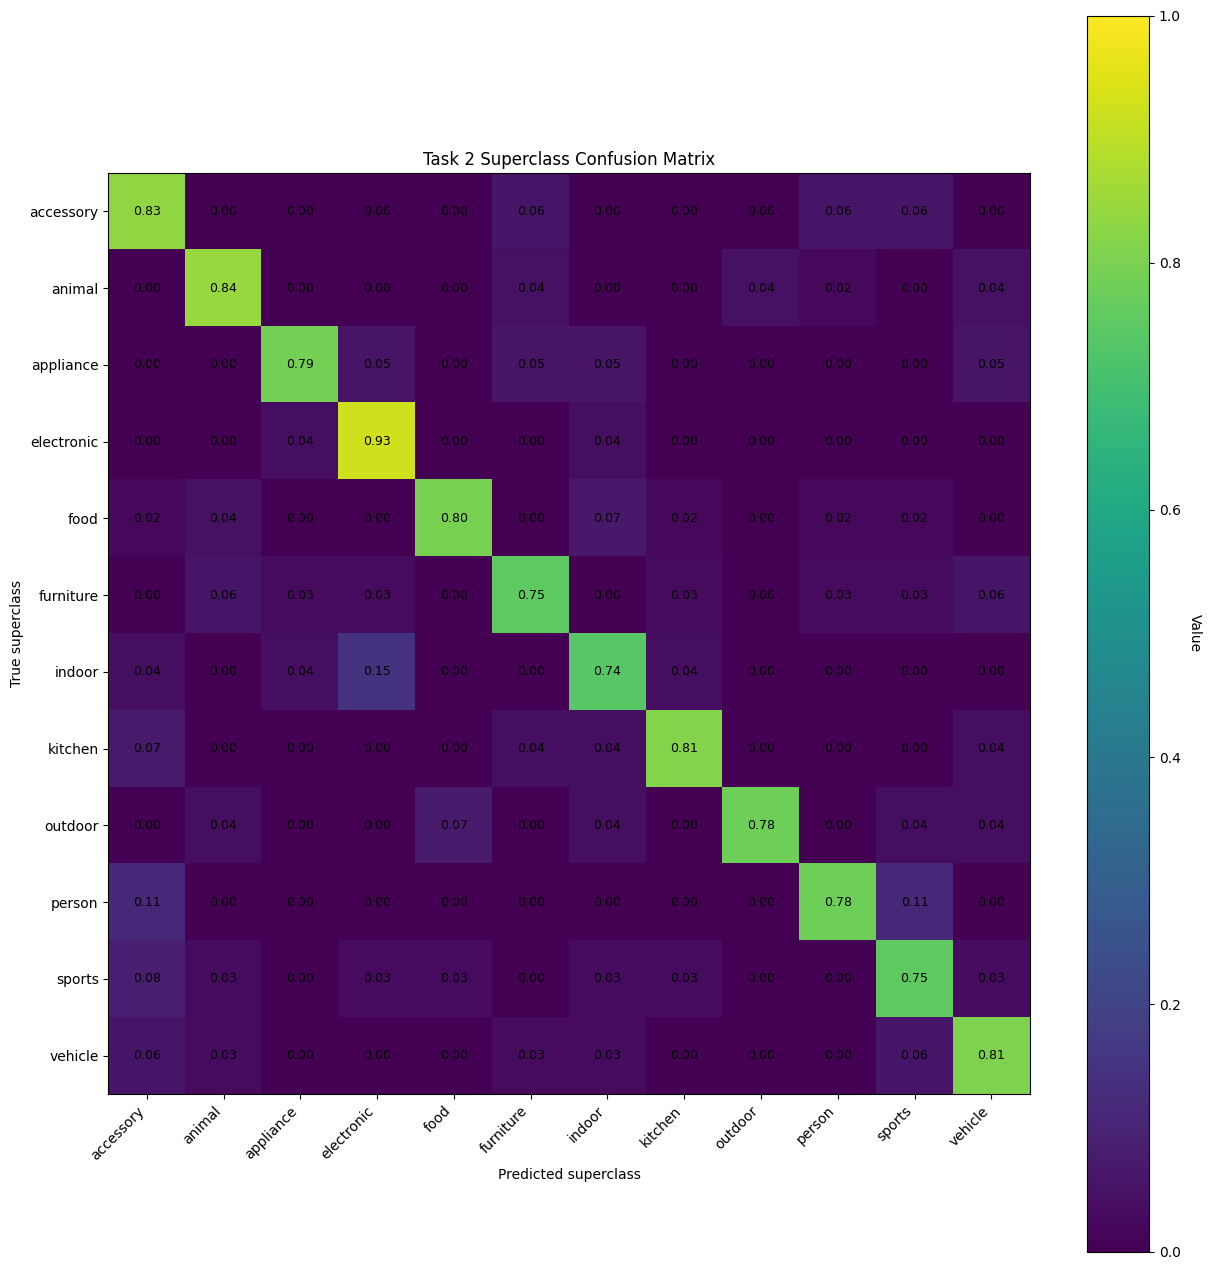


================ TASK 3 ================


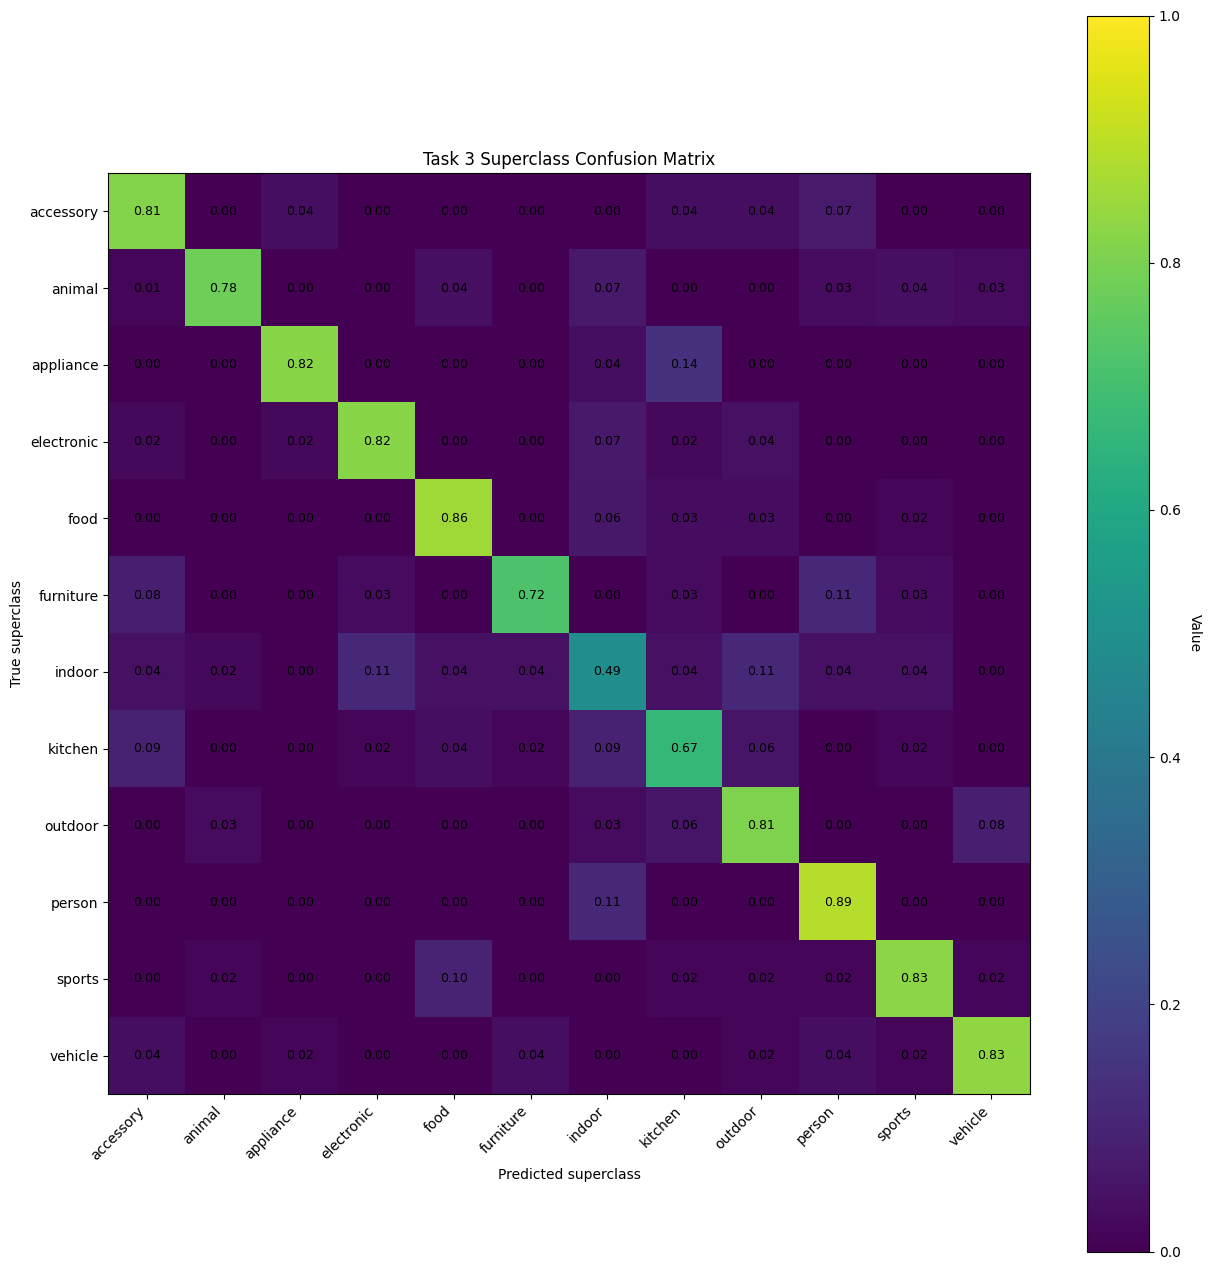


================ TASK 4 ================


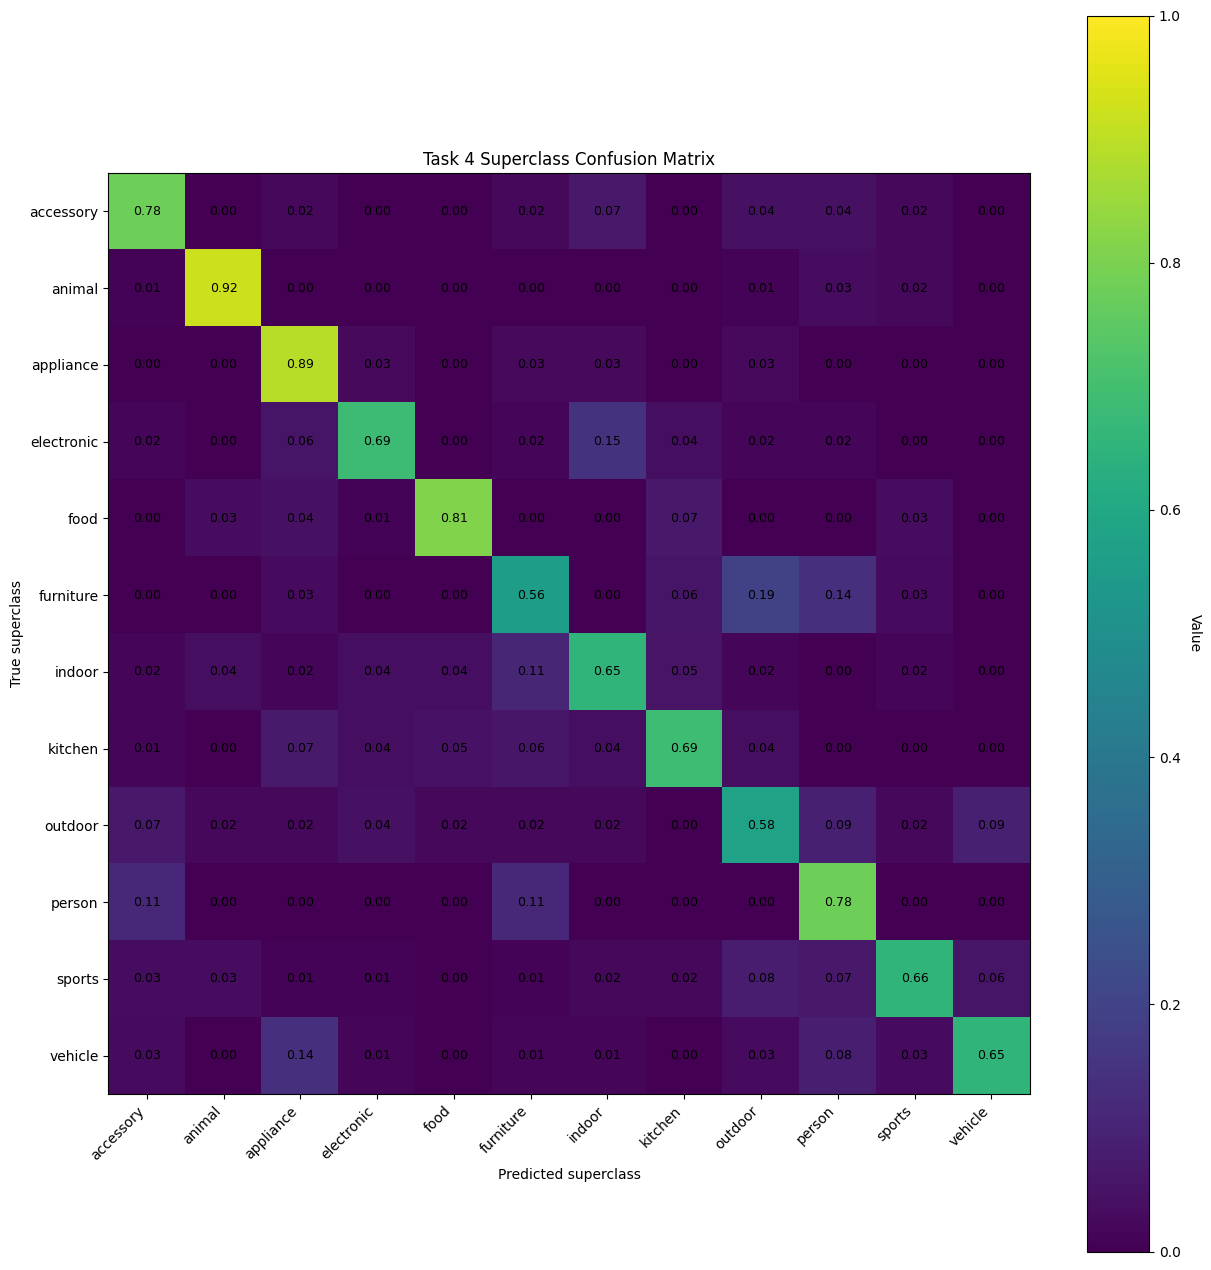

In [54]:
results, replay_buffer, per_task_details = run_incremental_fewshot(train_tasks, k=15)

summary_df = compact_summary_table(results, per_task_details)
print(summary_df)

for i in range(len(per_task_details)):
    print_task_report(per_task_details, i)

   task  task_accuracy  cross_superclass_error  mean_superclass_acc  \
0     1         0.9111                  0.0889               0.9057   

   std_superclass_acc  
0              0.0763  

================ TASK 1 ================


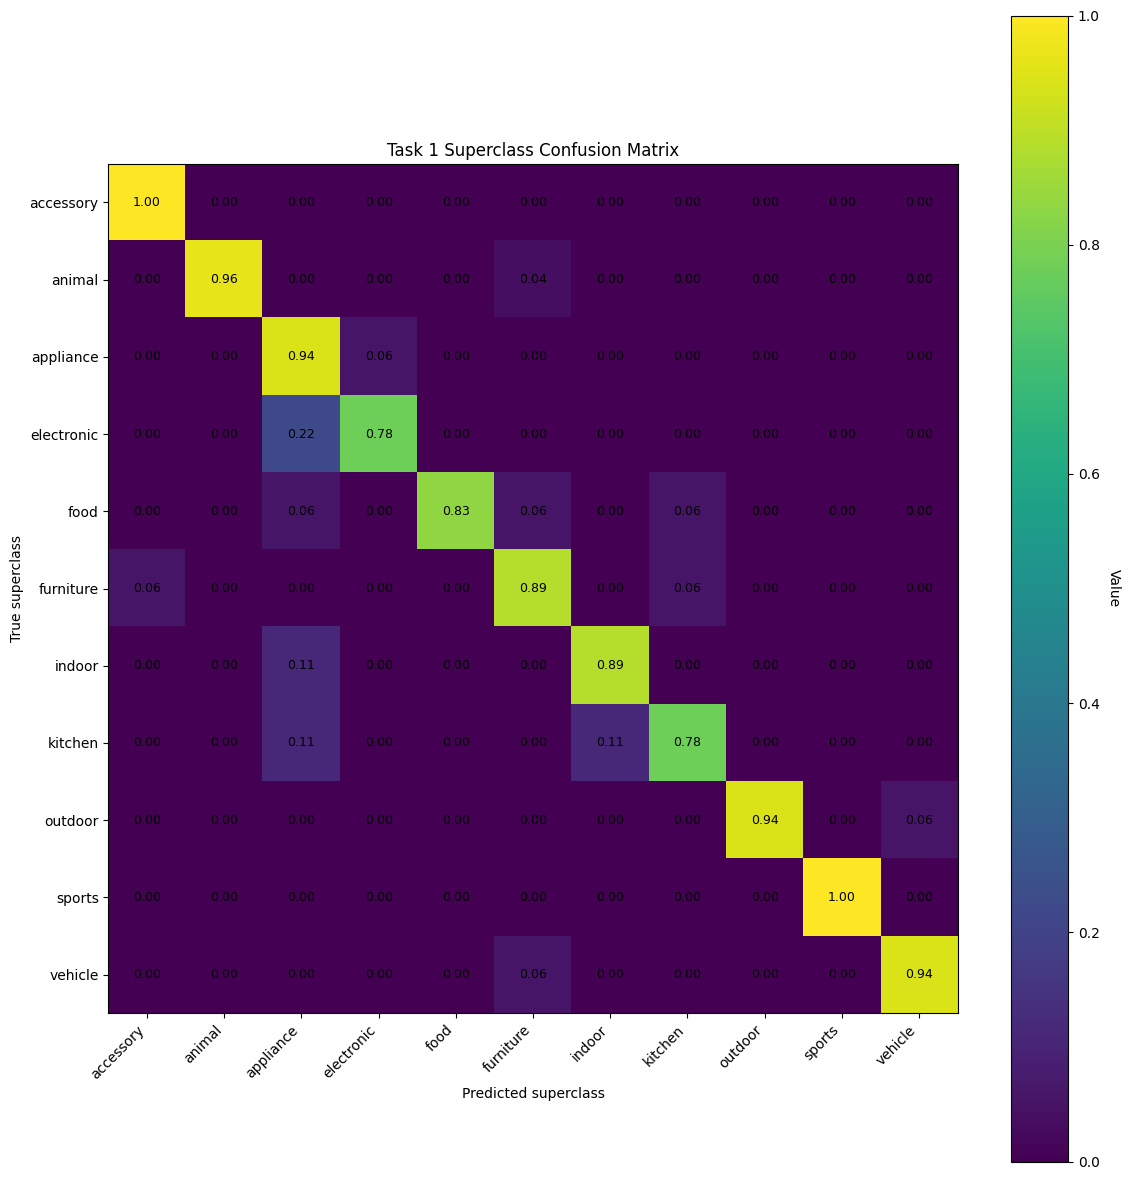

In [55]:
results, replay_buffer, per_task_details = run_incremental_fewshot(train_tasks[:1], k=15)

summary_df = compact_summary_table(results, per_task_details)
print(summary_df)

for i in range(len(per_task_details)):
    print_task_report(per_task_details, i)

   task  task_accuracy  cross_superclass_error  mean_superclass_acc  \
0     1         0.8944                  0.1056               0.9024   

   std_superclass_acc  
0              0.0945  

================ TASK 1 ================


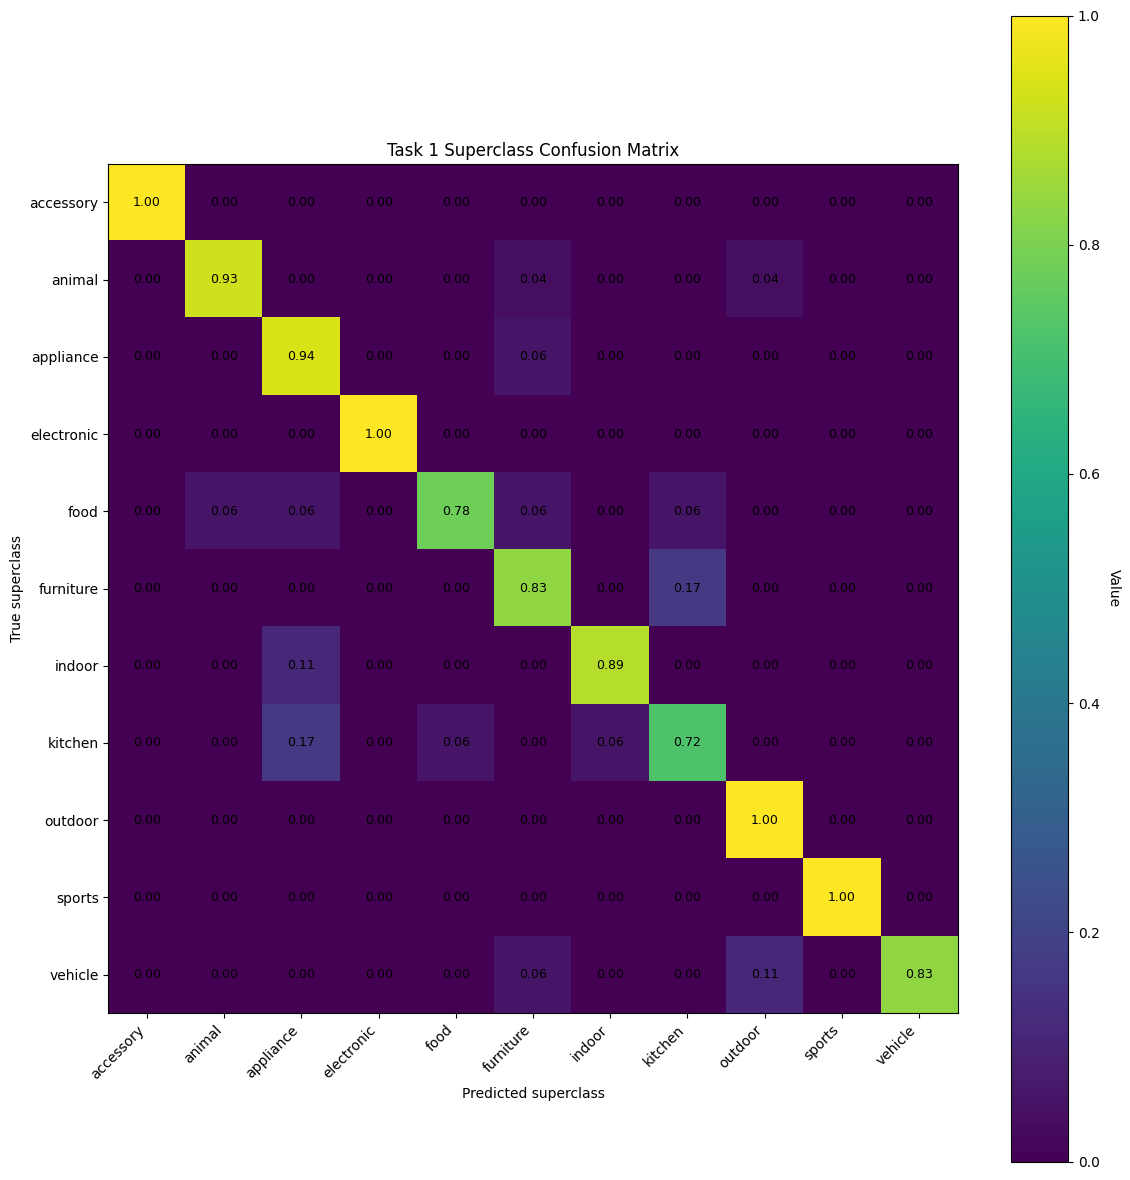

In [56]:
_, _, _ = run_incremental_fewshot(train_tasks[:2], k=15)
results, per_task_details = test_incremental_fewshot(test_tasks[:1])

summary_df = compact_summary_table(results, per_task_details)
print(summary_df)
print_task_report(per_task_details, 0)

   task  task_accuracy  cross_superclass_error  mean_superclass_acc  \
0     1         0.8778                  0.1222               0.8855   

   std_superclass_acc  
0              0.1205  

================ TASK 1 ================


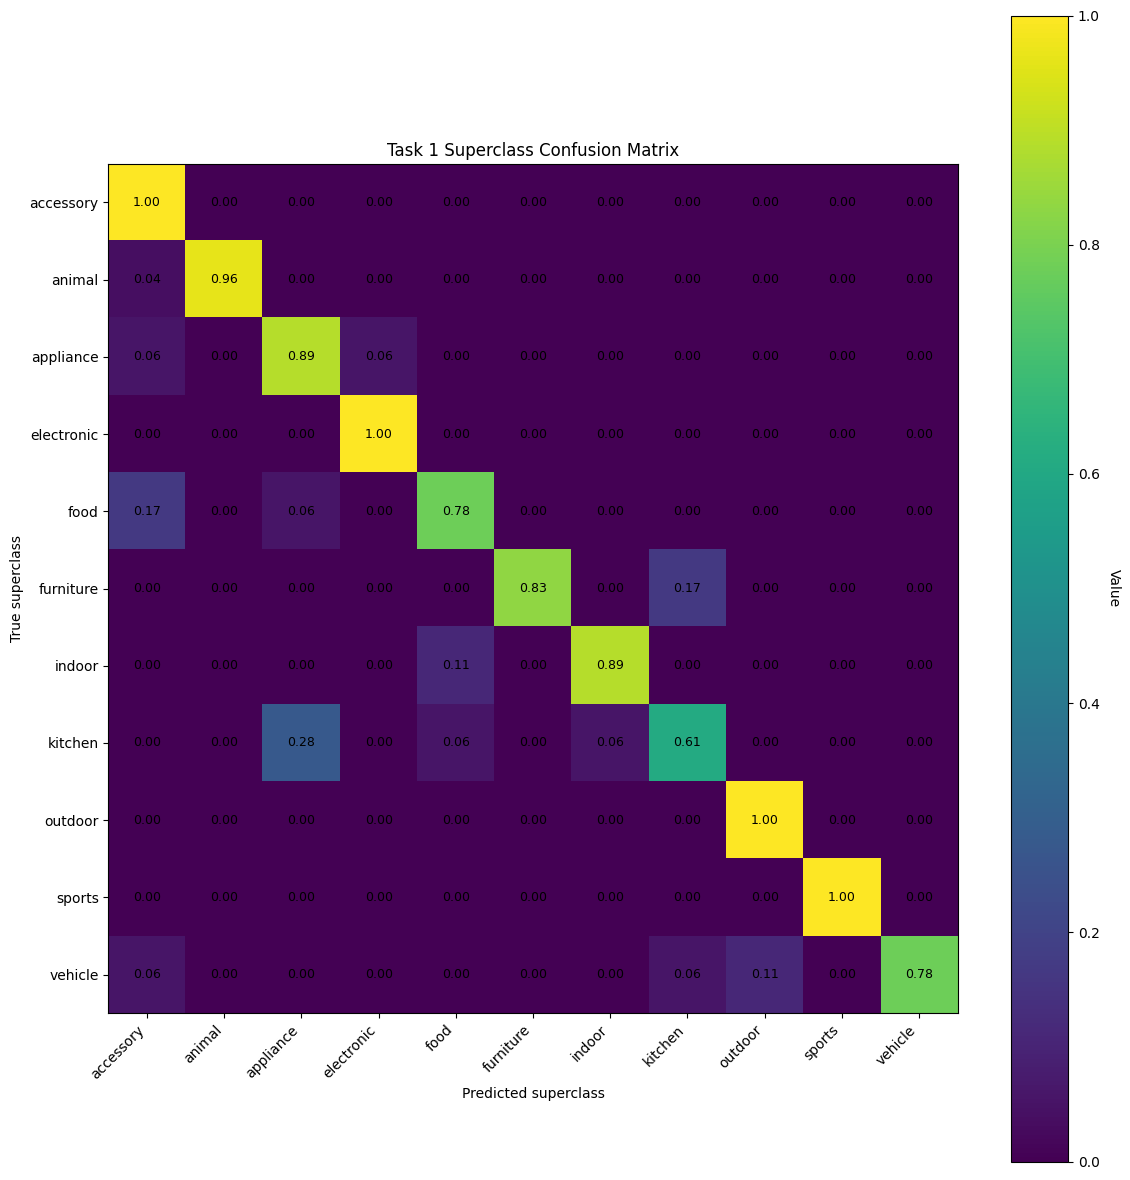

In [57]:
_, _, _ = run_incremental_fewshot(train_tasks[:3], k=15)
results, per_task_details = test_incremental_fewshot(test_tasks[:1])

summary_df = compact_summary_table(results, per_task_details)
print(summary_df)
print_task_report(per_task_details, 0)

   task  task_accuracy  cross_superclass_error  mean_superclass_acc  \
0     1         0.8833                  0.1167               0.9074   

   std_superclass_acc  
0              0.0961  

================ TASK 1 ================


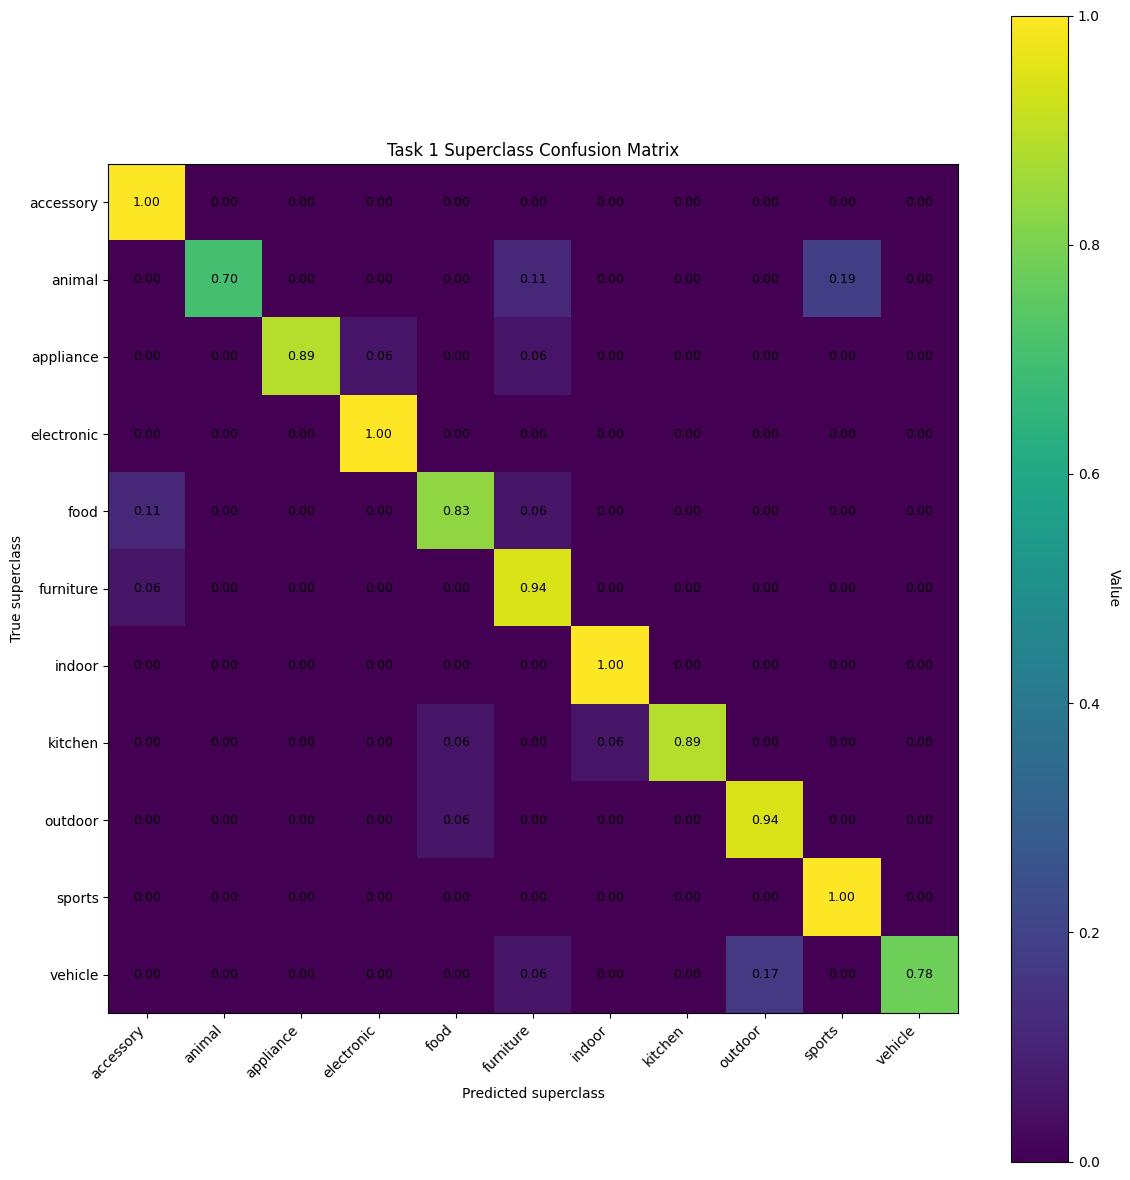

In [58]:
_, _, _ = run_incremental_fewshot(train_tasks, k=15)
results, per_task_details = test_incremental_fewshot(test_tasks[:1])

summary_df = compact_summary_table(results, per_task_details)
print(summary_df)
print_task_report(per_task_details, 0)

   task  task_accuracy  cross_superclass_error  mean_superclass_acc  \
0     1         0.8011                  0.1989               0.8008   

   std_superclass_acc  
0               0.049  

================ TASK 1 ================


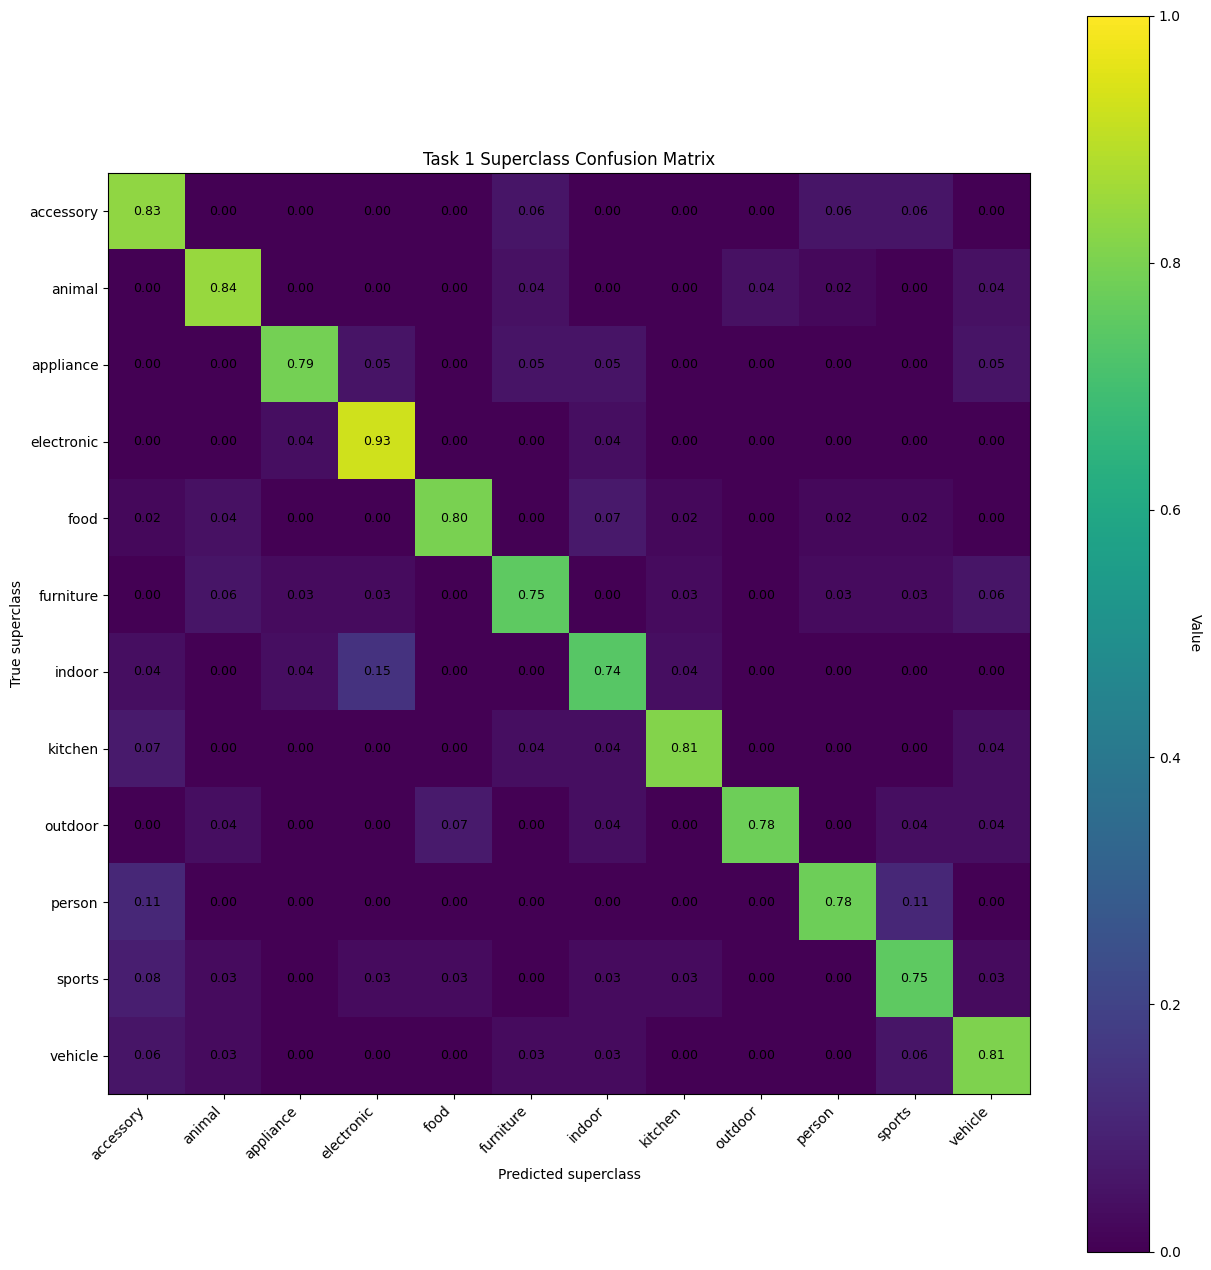

In [59]:
_, _, _ = run_incremental_fewshot(train_tasks[:2], k=15)
results, per_task_details = test_incremental_fewshot([test_tasks[1]])

summary_df = compact_summary_table(results, per_task_details)
print(summary_df)
print_task_report(per_task_details, 0)

   task  task_accuracy  cross_superclass_error  mean_superclass_acc  \
0     1         0.7926                  0.2074               0.7878   

   std_superclass_acc  
0              0.0614  

================ TASK 1 ================


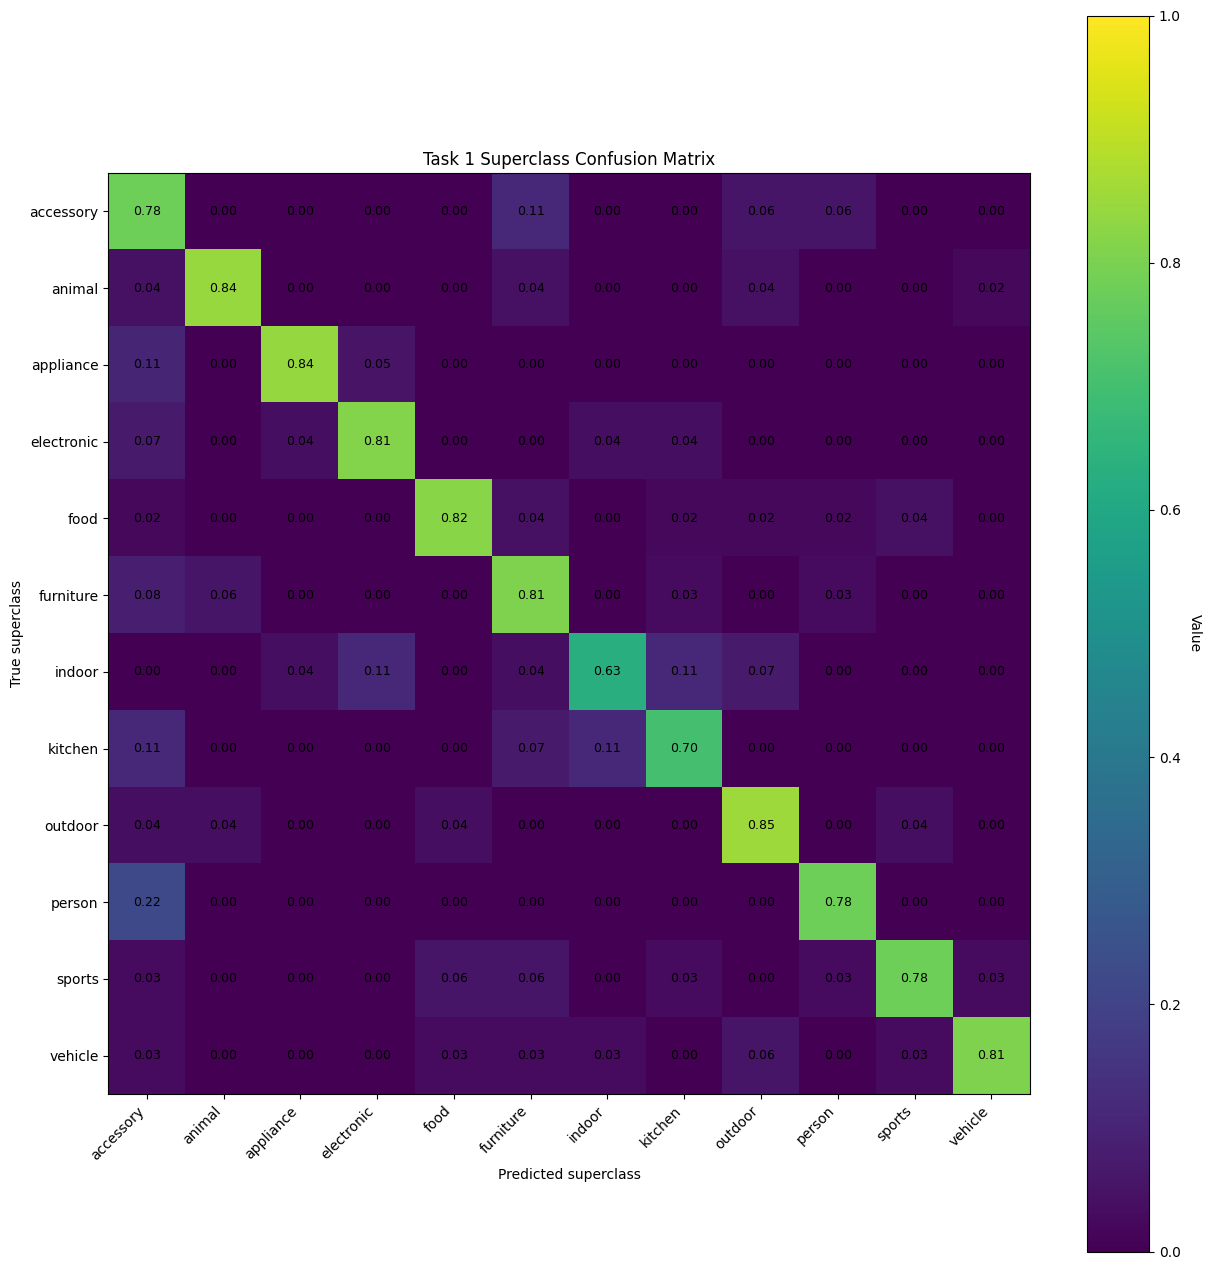

In [60]:
_, _, _ = run_incremental_fewshot(train_tasks[:3], k=15)
results, per_task_details = test_incremental_fewshot([test_tasks[1]])

summary_df = compact_summary_table(results, per_task_details)
print(summary_df)
print_task_report(per_task_details, 0)

   task  task_accuracy  cross_superclass_error  mean_superclass_acc  \
0     1         0.7727                  0.2273               0.7682   

   std_superclass_acc  
0              0.1113  

================ TASK 1 ================


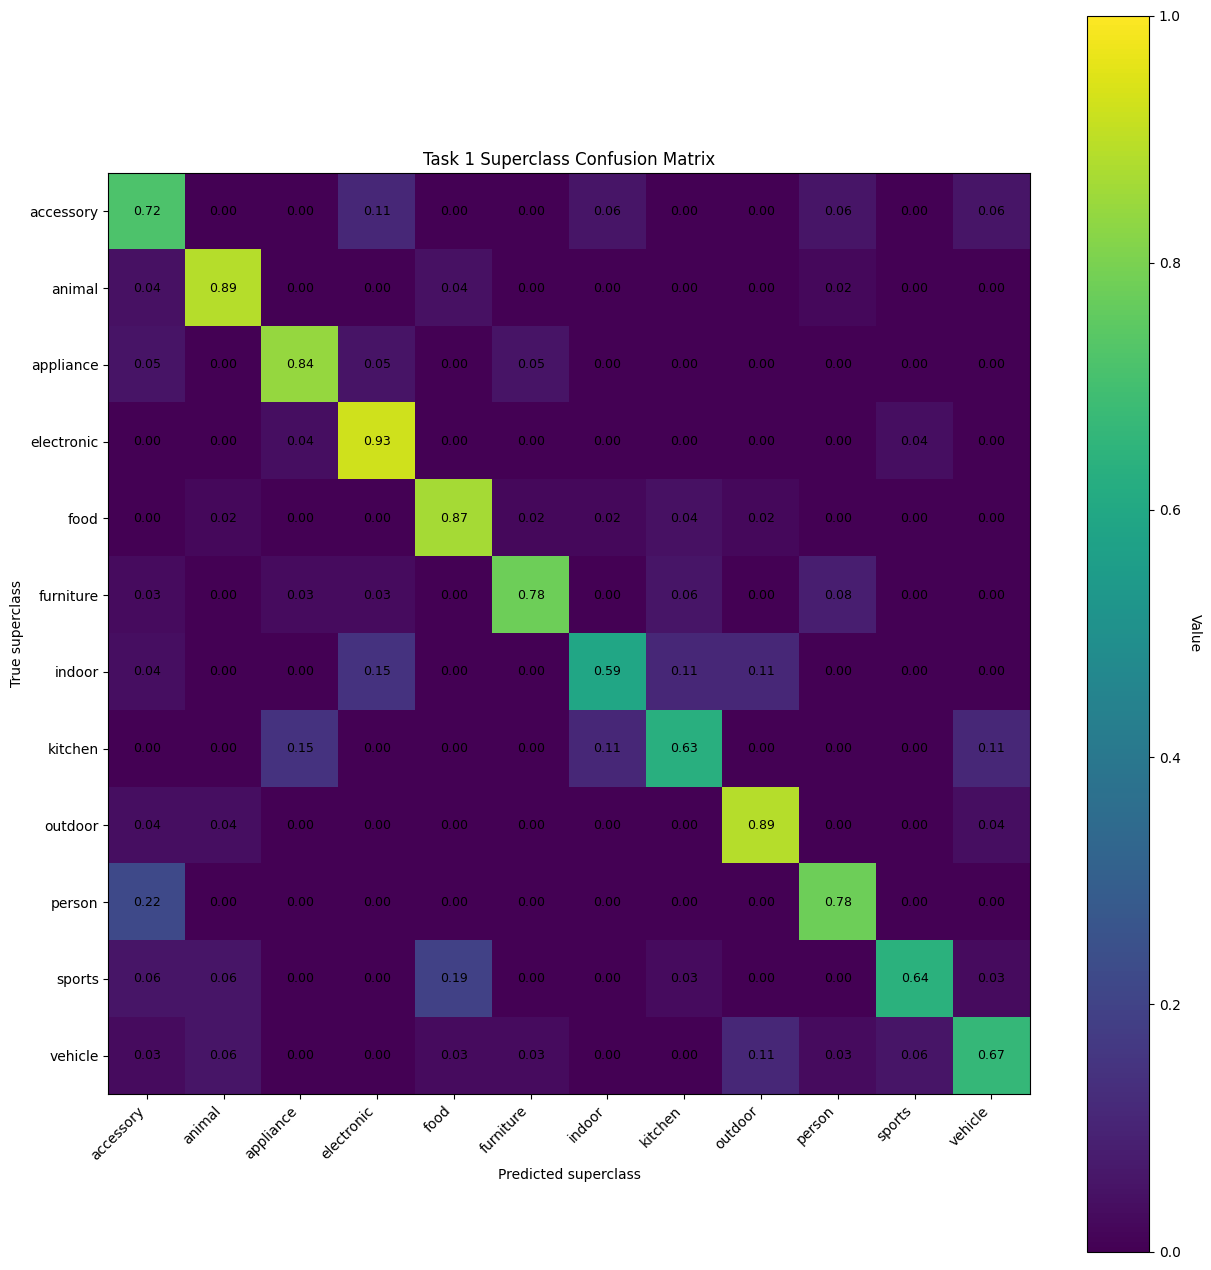

In [61]:
_, _, _ = run_incremental_fewshot(train_tasks, k=15)
results, per_task_details = test_incremental_fewshot([test_tasks[1]])

summary_df = compact_summary_table(results, per_task_details)
print(summary_df)
print_task_report(per_task_details, 0)

   task  task_accuracy  cross_superclass_error  mean_superclass_acc  \
0     1         0.7707                  0.2293                0.777   

   std_superclass_acc  
0              0.1036  

================ TASK 1 ================


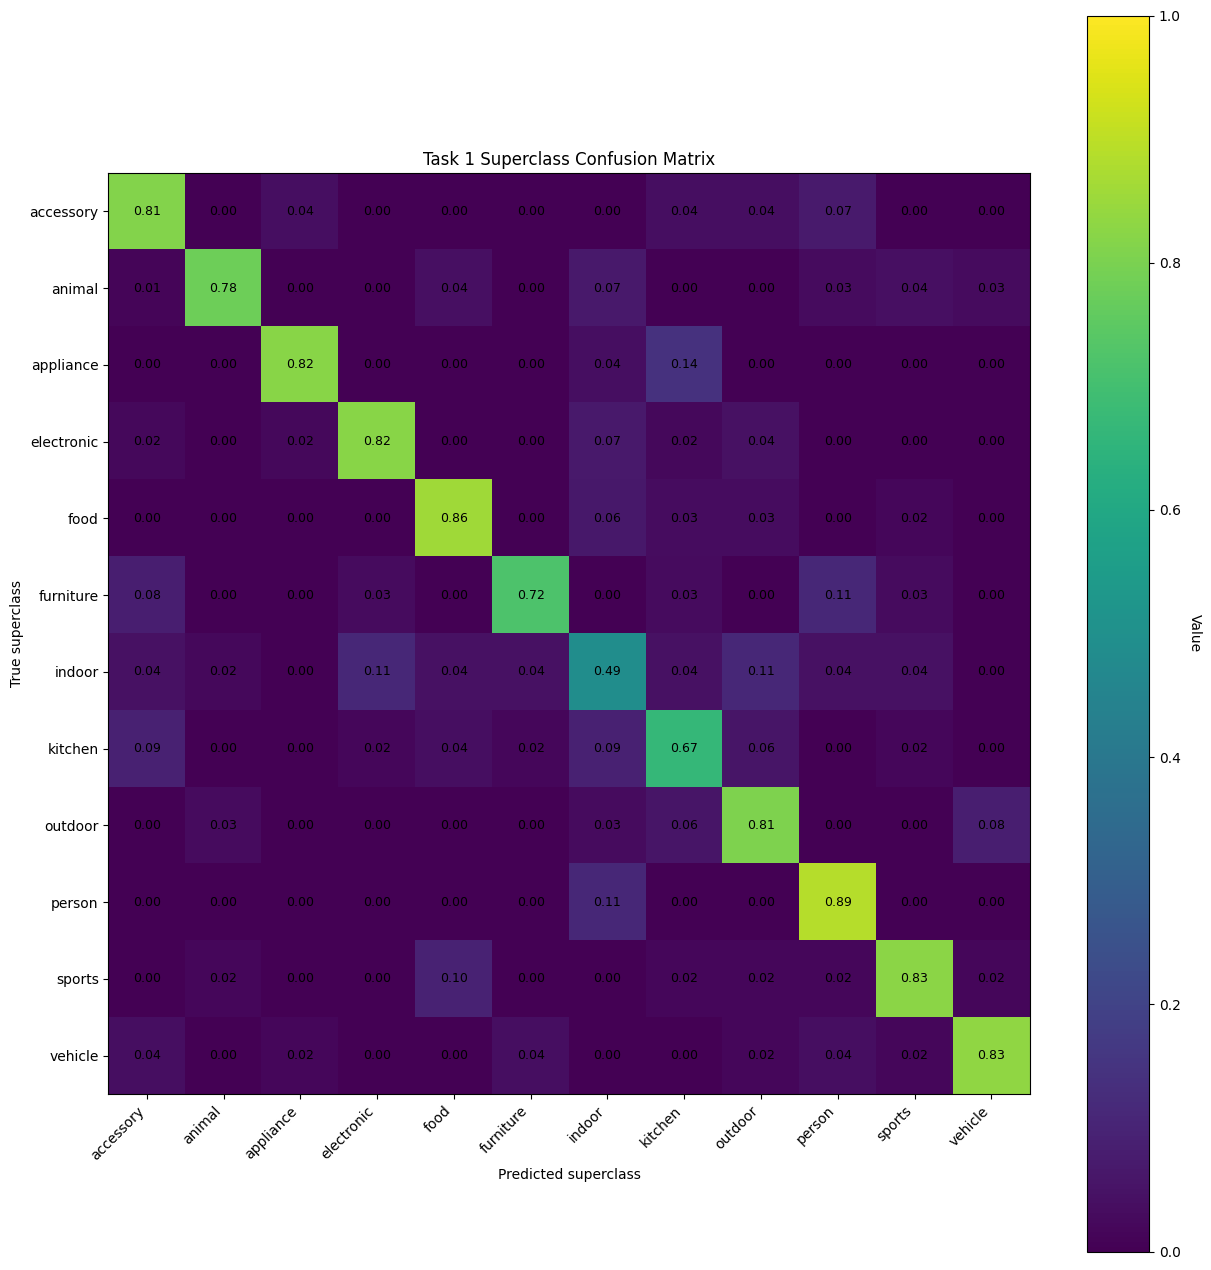

In [62]:
_, _, _ = run_incremental_fewshot(train_tasks[:3], k=15)
results, per_task_details = test_incremental_fewshot([test_tasks[2]])

summary_df = compact_summary_table(results, per_task_details)
print(summary_df)
print_task_report(per_task_details, 0)

   task  task_accuracy  cross_superclass_error  mean_superclass_acc  \
0     1         0.7368                  0.2632                0.746   

   std_superclass_acc  
0               0.158  

================ TASK 1 ================


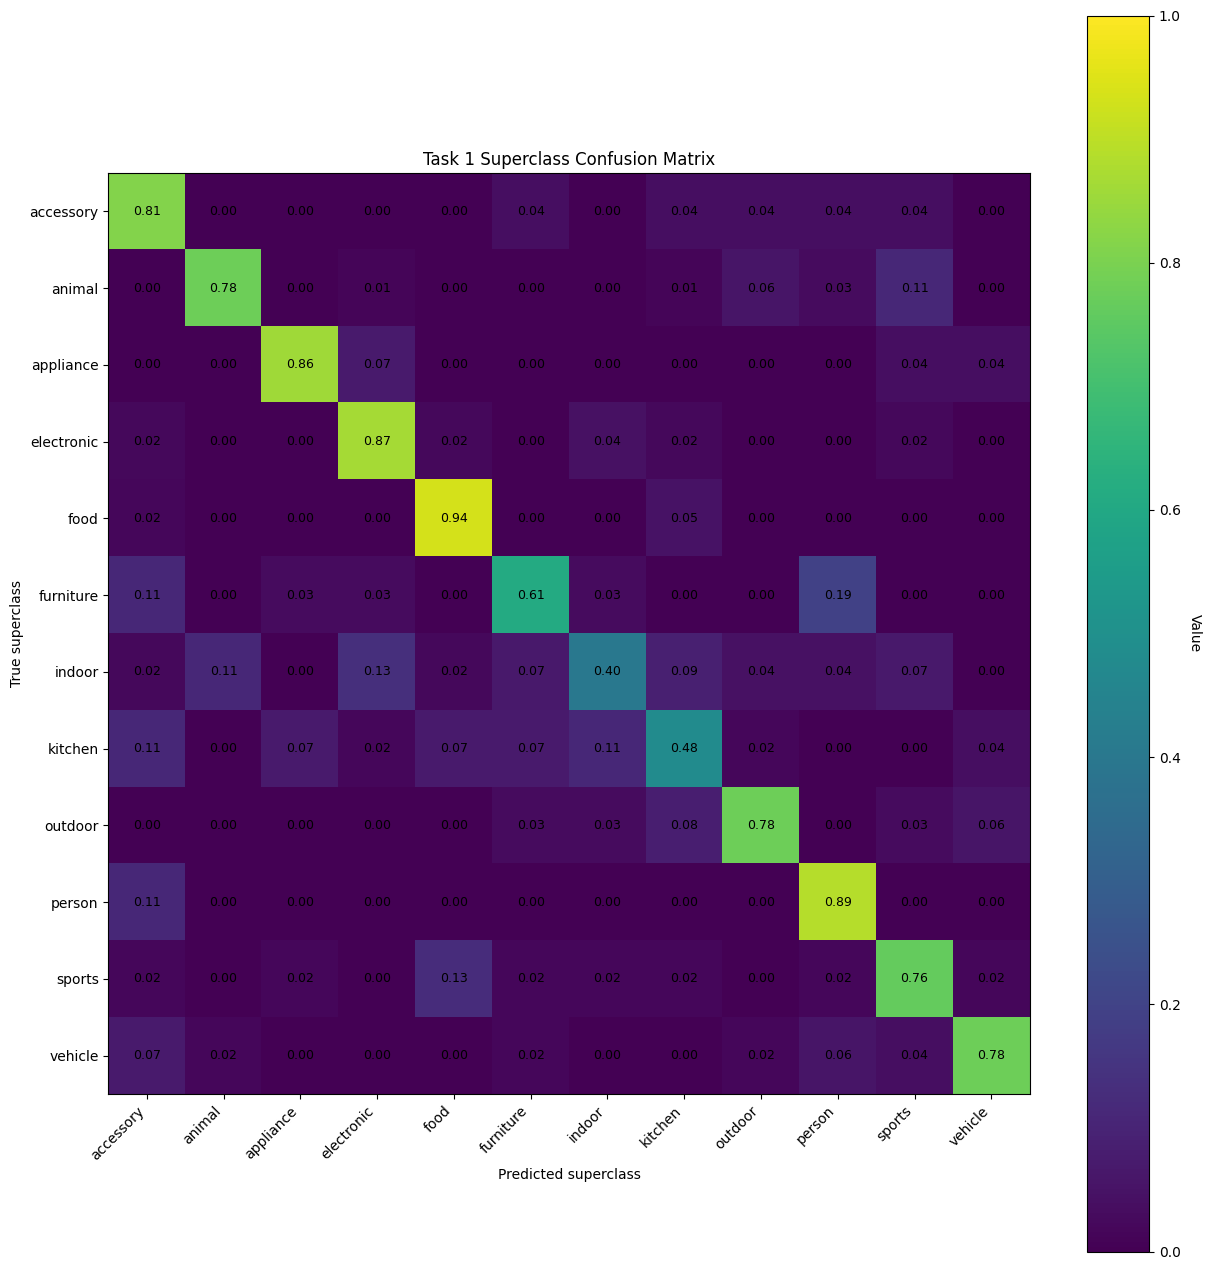

In [63]:
_, _, _ = run_incremental_fewshot(train_tasks, k=15)
results, per_task_details = test_incremental_fewshot([test_tasks[2]])

summary_df = compact_summary_table(results, per_task_details)
print(summary_df)
print_task_report(per_task_details, 0)

   task  task_accuracy  cross_superclass_error  mean_superclass_acc  \
0     1         0.7273                  0.2727               0.7211   

   std_superclass_acc  
0              0.1109  

================ TASK 1 ================


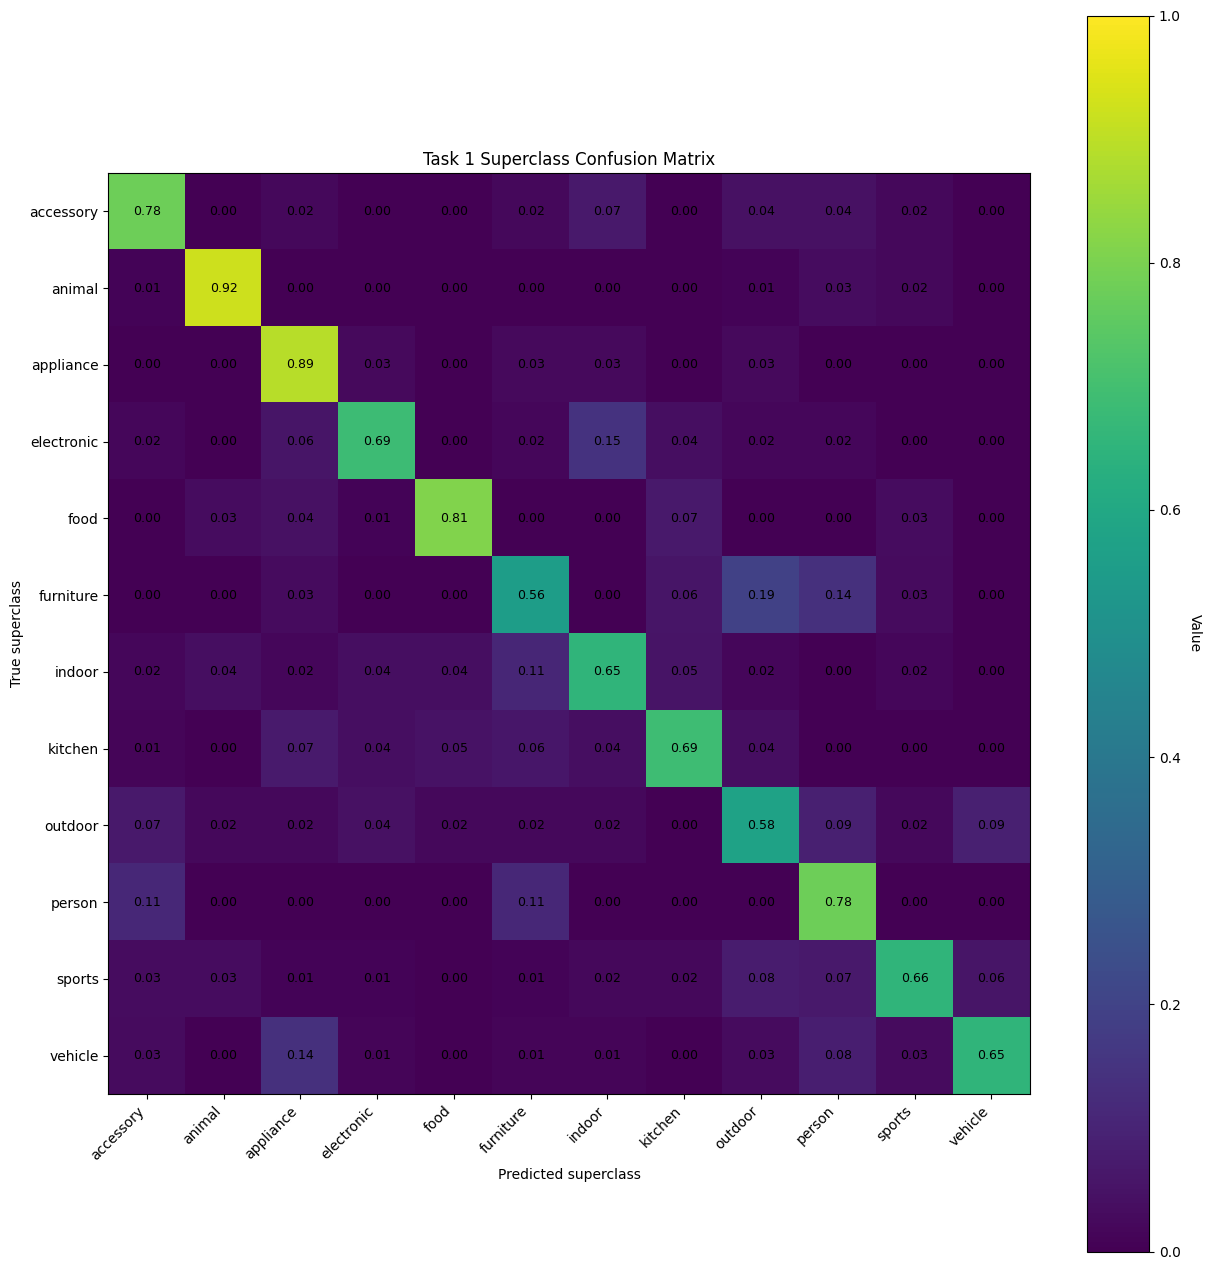

In [64]:
_, _, _ = run_incremental_fewshot(train_tasks, k=15)
results, per_task_details = test_incremental_fewshot([test_tasks[3]])

summary_df = compact_summary_table(results, per_task_details)
print(summary_df)
print_task_report(per_task_details, 0)

w/k-medoids


    T1      T2      T3      T4          forgetting
T1  0.9141  0.9152  0.8758  0.6005      0.3136

T2  -----   0.8539  0.7856  0.7784      0.0755

T3  -----   -----   0.7705  0.7766      -0.0071

T4  -----   -----   -----   0.7829      0.0000